# Build basic 2-Layer MLP to solve the xor-Problem

In [146]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs #for data generatio
from sklearn.model_selection import train_test_split #for test set generation
import torch
import torch.nn as nn


In [147]:
X, y = make_blobs(n_samples=200, n_features=2, cluster_std=.1
                  ,centers= [(1,1), (1,0), (0,0),(0,1)])

In [148]:
#make blobs into binary problem
y[y==2]=0
y[y==3]=1

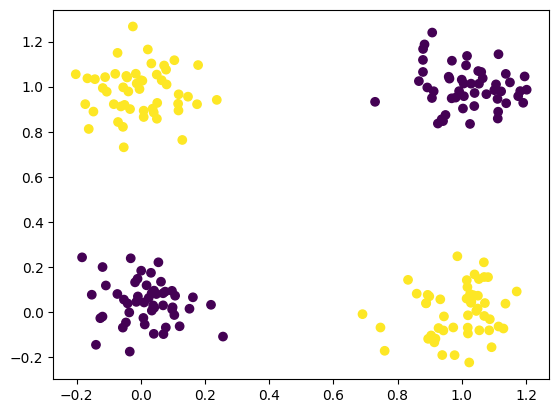

In [149]:
plt.scatter(X[:,0],X[:,1],c=y)

## Steps:
* build train and test sets
* write MLP class in Pytorch with two layers with adjustable number of perceptrons
* use nn.linear and nn.Sigmoid() units
* train your model
* test your model

Prepare Training and Test Data


In [150]:
#split in train and test
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

#np->torch
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

In [151]:
#have look
y_train

tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 0.,
        1., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1.,
        0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0.,
        1., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 0., 0., 1., 1., 1., 1., 1., 1.,
        0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1.,
        0., 1., 1., 0., 1., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1.,
        1., 0., 0., 1., 1., 0., 0., 1.])

Build Perceptrons

In [152]:
# Fine Declaration - Maybe nice to make
class MLP2Simple(torch.nn.Module):
    def __init__(self, hiddensize_1, hiddensize_2):
        super().__init__()
        self.fc1 = torch.nn.Linear(2,hiddensize_1)
        self.sigmoid1 = torch.nn.Sigmoid()

        self.fc2 = torch.nn.Linear(hiddensize_1,hiddensize_2)
        self.sigmoid2 = torch.nn.Sigmoid()

        self.fc3 = torch.nn.Linear(hiddensize_2,1)




    def forward(self, x):
        # Durch die Schichten propagieren
        x = self.sigmoid1(self.fc1(x))
        x = self.sigmoid2(self.fc2(x))
        x = self.fc3(x)  # Ausgangsschicht
        return x



Get Instance of Model

In [153]:
#get instance of perceptron model
model = MLP2Simple(25,12)

#define loss function
criterion = torch.nn.CrossEntropyLoss()

#define optimizer -> SGD with learning rate lr
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)


In [154]:
#run test data theogh untrained model
model.eval() #set to eval mode
model(x_test)

tensor([[-0.3907],
        [-0.3874],
        [-0.3958],
        [-0.3876],
        [-0.3880],
        [-0.3967],
        [-0.3860],
        [-0.3958],
        [-0.3888],
        [-0.3881],
        [-0.3958],
        [-0.3970],
        [-0.3956],
        [-0.3960],
        [-0.3873],
        [-0.3967],
        [-0.3898],
        [-0.3968],
        [-0.3965],
        [-0.3955],
        [-0.3898],
        [-0.3971],
        [-0.3956],
        [-0.3978],
        [-0.3969],
        [-0.3888],
        [-0.3884],
        [-0.3973],
        [-0.3965],
        [-0.3872],
        [-0.3959],
        [-0.3975],
        [-0.3976],
        [-0.3887],
        [-0.3957],
        [-0.3957],
        [-0.3885],
        [-0.3881],
        [-0.3884],
        [-0.3894],
        [-0.3973],
        [-0.3871],
        [-0.3875],
        [-0.3875],
        [-0.3971],
        [-0.3967],
        [-0.3964],
        [-0.3875],
        [-0.3967],
        [-0.3959],
        [-0.3864],
        [-0.3869],
        [-0.

In [155]:
model.train() #set to train mode
epoch = 50
for epoch in range(epoch):
    optimizer.zero_grad()
    # Forward pass
    y_pred = model(x_train)
    # Compute Loss
    loss = criterion(y_pred.squeeze(), y_train)

    print('Epoch {}: train loss: {}'.format(epoch, loss.item()))
    # Backward pass
    loss.backward()
    #make gradient update
    optimizer.step()

Epoch 0: train loss: 318.3524169921875
Epoch 1: train loss: 318.352294921875
Epoch 2: train loss: 318.3522644042969
Epoch 3: train loss: 318.3521728515625
Epoch 4: train loss: 318.3520812988281
Epoch 5: train loss: 318.3520202636719
Epoch 6: train loss: 318.3519592285156
Epoch 7: train loss: 318.35186767578125
Epoch 8: train loss: 318.3517761230469
Epoch 9: train loss: 318.35174560546875
Epoch 10: train loss: 318.35162353515625
Epoch 11: train loss: 318.3515625
Epoch 12: train loss: 318.35150146484375
Epoch 13: train loss: 318.3514404296875
Epoch 14: train loss: 318.3513488769531
Epoch 15: train loss: 318.3512878417969
Epoch 16: train loss: 318.3511962890625
Epoch 17: train loss: 318.35113525390625
Epoch 18: train loss: 318.35107421875
Epoch 19: train loss: 318.3509521484375
Epoch 20: train loss: 318.35089111328125
Epoch 21: train loss: 318.350830078125
Epoch 22: train loss: 318.35076904296875
Epoch 23: train loss: 318.3507080078125
Epoch 24: train loss: 318.35064697265625
Epoch 25: tr

Evaluate

In [156]:
model.eval() #set model to eval mode

#train
y_pred = model(x_train) #predict
y_pred=(y_pred>0.5).int().flatten() #argmax class lable
train_acc =torch.sum(y_pred == y_train.int())/ y_train.shape[0]
print("train ACC: ",train_acc.float())

train ACC:  tensor(0.5149)


In [157]:
#test
y_pred = model(x_test) #predict
y_pred=(y_pred>0.5).int().flatten() #argmax class lable
test_acc = torch.sum(y_pred == y_test.int()) / y_test.shape[0]
print("test ACC: ",test_acc.float())

test ACC:  tensor(0.4697)


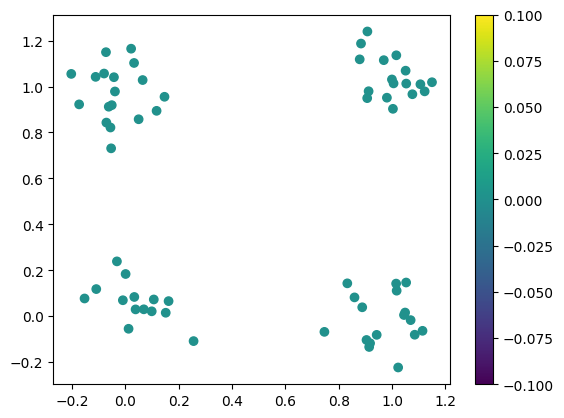

In [158]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_pred)
plt.colorbar()